# MScFE 620: DERIVATIVE PRICING
## Group Work Project 2 (Group 13438)

---

### Project Overview
This project assesses the causes and impacts of volatility by transitioning from the standard Black-Scholes framework to advanced continuous-time models. Specifically, it implements the **Heston Model** to account for stochastic volatility and the **Merton (1976) Model** to account for discontinuous stock price jumps. The objective is to evaluate the sensitivity of European, American, and Barrier options to these dynamic parameters using Monte Carlo simulations.

### Key Parameters
Based on the project requirements, the models utilize the following baseline inputs:

**Global Market Inputs:**
- **Initial Stock Price ($S_0$):** $80
- **Strike Price ($K$):** $80 (ATM)
- **Risk-Free Rate ($r$):** 5.5%
- **Diffusive Volatility ($\sigma$):** 35%
- **Time to Maturity ($T$):** 3 months (0.25 years)

**Heston Model Parameters:**
- **Initial Variance ($v_0$):** 3.2% (0.032)
- **Mean Reversion Rate ($\kappa$):** 1.85
- **Long-run Variance ($\theta$):** 0.045
- **Volatility of Variance ($\sigma_v$):** 30%

**Merton Model Parameters:**
- **Mean Jump Size ($\mu_j$):** -0.5
- **Volatility of Jump ($\delta_j$):** 0.22

**Simulation Setup:**
- **Monte Carlo Paths ($I$):** 50,000
- **Time Steps ($M$):** 250
- **Finite Difference Bump ($h$):** $0.01

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from IPython.display import display

# Output formatting
pd.set_option('display.float_format', '{:.4f}'.format)

# ==========================================
# 1. GLOBAL PARAMETERS
# ==========================================
S0 = 80.0
r = 0.055
sigma_bs = 0.35
T = 3.0 / 12.0
K_ATM = 80.0

# Heston Parameters
v0 = 0.032
kappa = 1.85
theta = 0.045
sigma_v = 0.30

# Merton Parameters
mu_j = -0.5
delta_j = 0.22

# Monte Carlo Parameters
N_sim = 50000
N_steps = 250
dt = T / N_steps
BASE_SEED = 42
h = 0.01

### Core Path Generators & Pricing Functions
The following functions implement the discretized Stochastic Differential Equations (SDEs) for the Heston and Merton models using Euler-Maruyama approximations. These generators return the full stock price paths, which are utilized for pricing Vanilla, American, and Barrier options consistently.

In [ ]:
# ==========================================
# 2. PATH GENERATORS & PRICERS
# ==========================================

def heston_paths(S0, r, v0, kappa, theta, sigma_v, rho, T, N_steps, N_sim, seed=None):
    """Simulate full Heston paths using Euler-Maruyama with full truncation."""
    if seed is not None: np.random.seed(seed)
    dt = T / N_steps
    S = np.zeros((N_steps + 1, N_sim))
    v = np.zeros((N_steps + 1, N_sim))
    S[0] = S0
    v[0] = v0
    sqrt_1_rho2 = np.sqrt(max(1 - rho**2, 0.0))

    Z1 = np.random.standard_normal((N_steps, N_sim))
    Z2 = np.random.standard_normal((N_steps, N_sim))
    W1 = Z1
    W2 = rho * Z1 + sqrt_1_rho2 * Z2

    for t in range(N_steps):
        v_pos = np.maximum(v[t], 0.0)
        sv_dt = np.sqrt(v_pos * dt)
        S[t + 1] = S[t] * np.exp((r - 0.5 * v_pos) * dt + sv_dt * W1[t])
        v[t + 1] = v_pos + kappa * (theta - v_pos) * dt + sigma_v * sv_dt * W2[t]
    return S

def merton_paths(S0, r, sigma, T, lamb, mu_j, delta_j, N_steps, N_sim, seed=None):
    """Simulate full Merton jump-diffusion paths."""
    if seed is not None: np.random.seed(seed)
    dt = T / N_steps
    SM = np.zeros((N_steps + 1, N_sim))
    SM[0] = S0
    rj = lamb * (np.exp(mu_j + 0.5 * delta_j**2) - 1)

    z1 = np.random.standard_normal((N_steps + 1, N_sim))
    z2 = np.random.standard_normal((N_steps + 1, N_sim))
    y  = np.random.poisson(lamb * dt, (N_steps + 1, N_sim))

    for t in range(1, N_steps + 1):
        SM[t] = SM[t - 1] * (
            np.exp((r - rj - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z1[t])
            + (np.exp(mu_j + delta_j * z2[t]) - 1) * y[t]
        )
        SM[t] = np.maximum(SM[t], 0.00001)
    return SM

def euro_call_price_mc(S_paths, K, r, T):
    return np.exp(-r * T) * np.maximum(S_paths[-1] - K, 0.0).mean()

def euro_put_price_mc(S_paths, K, r, T):
    return np.exp(-r * T) * np.maximum(K - S_paths[-1], 0.0).mean()

def bs_call(S, K, r, T, sigma):
    """Black-Scholes European call price."""
    if sigma <= 0 or T <= 0:
        return max(float(S) - float(K) * np.exp(-r * T), 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return float(S) * norm.cdf(d1) - float(K) * np.exp(-r * T) * norm.cdf(d2)

def implied_vol(price, S, K, r, T, lo=1e-6, hi=5.0):
    """Implied volatility via Brent root-finding on the BS call formula."""
    try:
        intrinsic = max(float(S) - float(K) * np.exp(-r * T), 0.0)
        if price <= intrinsic + 1e-8:
            return np.nan
        return brentq(
            lambda sig: bs_call(S, K, r, T, sig) - price,
            lo, hi, xtol=1e-8
        )
    except ValueError:
        return np.nan

---
### Step 1: Stochastic Volatility Modeler (Team Member A)
**Questions 5, 6, and 7**
Pricing ATM European options under the Heston model, analyzing the impact of correlation ($\rho$), and calculating Delta and Gamma via finite differences using Common Random Numbers (CRN).

In [ ]:
import pandas as pd
rho_list = [-0.30, -0.70]
results_A = []

for rho in rho_list:
    S_paths = heston_paths(S0, r, v0, kappa, theta, sigma_v, rho, T, N_steps, N_sim, seed=BASE_SEED)
    c = euro_call_price_mc(S_paths, K_ATM, r, T)
    p = euro_put_price_mc(S_paths, K_ATM, r, T)

    # Bump paths for Greeks (CRN)
    S_up = heston_paths(S0+h, r, v0, kappa, theta, sigma_v, rho, T, N_steps, N_sim, seed=BASE_SEED)
    S_dn = heston_paths(S0-h, r, v0, kappa, theta, sigma_v, rho, T, N_steps, N_sim, seed=BASE_SEED)

    c_up = euro_call_price_mc(S_up, K_ATM, r, T)
    c_dn = euro_call_price_mc(S_dn, K_ATM, r, T)
    p_up = euro_put_price_mc(S_up, K_ATM, r, T)
    p_dn = euro_put_price_mc(S_dn, K_ATM, r, T)

    cd_val = (c_up - c_dn) / (2 * h)
    cg_val = (c_up - 2 * c + c_dn) / (h ** 2)
    pd_val = (p_up - p_dn) / (2 * h)
    pg_val = (p_up - 2 * p + p_dn) / (h ** 2)

    results_A.append({
        "Question": "Q5" if rho == -0.30 else "Q6",
        "Rho": rho,
        "Call Price ($)": round(c, 2),
        "Put Price ($)": round(p, 2),
        "Call Delta": round(cd_val, 4),
        "Call Gamma": round(cg_val, 4),
        "Put Delta": round(pd_val, 4),
        "Put Gamma": round(pg_val, 4)
    })

df_A = pd.DataFrame(results_A)
print("Team A Output (Questions 5, 6, & 7):")
display(df_A)

Team A Output (Questions 5, 6, & 7):


,Question,Rho,Call Price ($),Put Price ($),Call Delta,Call Gamma,Put Delta,Put Gamma
0,Q5,-0.3000,3.4800,2.4100,0.5995,0.0489,-0.4001,0.0489
1,Q6,-0.7000,3.5000,2.4300,0.6237,0.0425,-0.3760,0.0425


---
### Step 1: Jump Modeler (Team Member B)
**Questions 8, 9, and 10**
Pricing ATM European options under the Merton jump-diffusion model, evaluating the impact of varying jump intensities ($\lambda$), and calculating the corresponding sensitivities.

In [ ]:
import pandas as pd
lambda_list = [0.75, 0.25]
results_B = []

for lamb in lambda_list:
    S_paths = merton_paths(S0, r, sigma_bs, T, lamb, mu_j, delta_j, N_steps, N_sim, seed=BASE_SEED)
    c = euro_call_price_mc(S_paths, K_ATM, r, T)
    p = euro_put_price_mc(S_paths, K_ATM, r, T)

    # Bump paths for Greeks (CRN)
    S_up = merton_paths(S0+h, r, sigma_bs, T, lamb, mu_j, delta_j, N_steps, N_sim, seed=BASE_SEED)
    S_dn = merton_paths(S0-h, r, sigma_bs, T, lamb, mu_j, delta_j, N_steps, N_sim, seed=BASE_SEED)

    c_up = euro_call_price_mc(S_up, K_ATM, r, T)
    c_dn = euro_call_price_mc(S_dn, K_ATM, r, T)
    p_up = euro_put_price_mc(S_up, K_ATM, r, T)
    p_dn = euro_put_price_mc(S_dn, K_ATM, r, T)

    # Use unique names to avoid overwriting 'pd' (pandas)
    cd_val = (c_up - c_dn) / (2 * h)
    cg_val = (c_up - 2 * c + c_dn) / (h ** 2)
    pd_val = (p_up - p_dn) / (2 * h)
    pg_val = (p_up - 2 * p + p_dn) / (h ** 2)

    results_B.append({
        "Question": "Q8" if lamb == 0.75 else "Q9",
        "Lambda": lamb,
        "Call Price ($)": round(c, 2),
        "Put Price ($)": round(p, 2),
        "Call Delta": round(cd_val, 4),
        "Call Gamma": round(cg_val, 4),
        "Put Delta": round(pd_val, 4),
        "Put Gamma": round(pg_val, 4)
    })

df_B = pd.DataFrame(results_B)
print("Team B Output (Questions 8, 9, & 10):")
display(df_B)

Team B Output (Questions 8, 9, & 10):


,Question,Lambda,Call Price ($),Put Price ($),Call Delta,Call Gamma,Put Delta,Put Gamma
0,Q8,0.7500,8.2700,7.2200,0.6481,0.0310,-0.3514,0.0310
1,Q9,0.2500,6.7900,5.7300,0.5959,0.0227,-0.4037,0.0227


---
### Step 1: Model Validator (Team Member C)
**Questions 11 and 12**
Verifying Put-Call Parity across both Heston and Merton specifications, and generating the implied Volatility Smile across 7 equally spaced strikes.

Theoretical C - P = S0 - K*exp(-rT) = 1.0925

Q11: Put-Call Parity Check:


,Question,Model,Param,Call ($),Put ($),C - P,Theoretical,Diff (Noise),Parity OK?
0,Q5,Heston,rho = -0.3,3.4800,2.4100,1.0700,1.0925,0.0225,Yes
1,Q6,Heston,rho = -0.7,3.5000,2.4300,1.0700,1.0925,0.0225,Yes
2,Q8,Merton,lambda = 0.75,8.2700,7.2200,1.0500,1.0925,0.0425,Yes
3,Q9,Merton,lambda = 0.25,6.7900,5.7300,1.0600,1.0925,0.0325,Yes


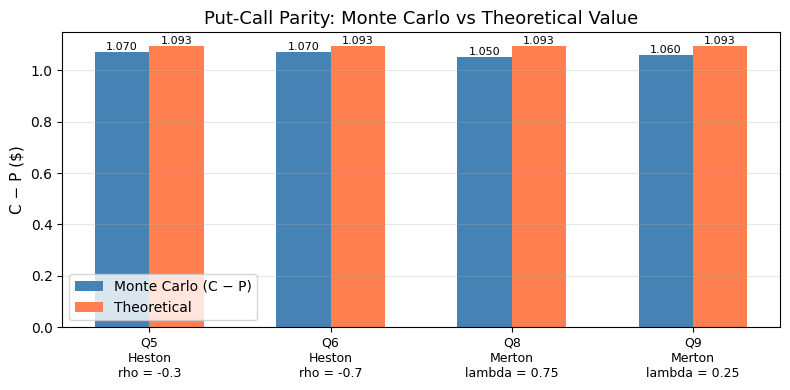

In [ ]:
# Q11: Put-Call Parity Verification
theoretical_diff = S0 - K_ATM * np.exp(-r * T)
print(f"Theoretical C - P = S0 - K*exp(-rT) = {theoretical_diff:.4f}\n")

parity_data = []
# Merge results from Team A and Team B for validation
for row in results_A:
    c, p = row["Call Price ($)"], row["Put Price ($)"]
    diff = c - p
    ok = 'Yes' if abs(diff - theoretical_diff) < 0.15 else 'No'
    parity_data.append({
        "Question": row["Question"],
        "Model": "Heston",
        "Param": f"rho = {row['Rho']}",
        "Call ($)": c,
        "Put ($)": p,
        "C - P": round(diff, 4),
        "Theoretical": round(theoretical_diff, 4),
        "Diff (Noise)": round(abs(diff - theoretical_diff), 4),
        "Parity OK?": ok
    })

for row in results_B:
    c, p = row["Call Price ($)"], row["Put Price ($)"]
    diff = c - p
    ok = 'Yes' if abs(diff - theoretical_diff) < 0.15 else 'No'
    parity_data.append({
        "Question": row["Question"],
        "Model": "Merton",
        "Param": f"lambda = {row['Lambda']}",
        "Call ($)": c,
        "Put ($)": p,
        "C - P": round(diff, 4),
        "Theoretical": round(theoretical_diff, 4),
        "Diff (Noise)": round(abs(diff - theoretical_diff), 4),
        "Parity OK?": ok
    })

df_parity = pd.DataFrame(parity_data)
print("Q11: Put-Call Parity Check:")
display(df_parity)

# ── Q11 Visualization: Put-Call Parity ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"{r['Question']}\n{r['Model']}\n{r['Param']}" for _, r in df_parity.iterrows()]
x = np.arange(len(labels))
width = 0.30

bars1 = ax.bar(x - width/2, df_parity['C - P'],       width, label='Monte Carlo (C − P)', color='steelblue')
bars2 = ax.bar(x + width/2, df_parity['Theoretical'],  width, label='Theoretical',          color='coral')

ax.bar_label(bars1, fmt='%.3f', fontsize=8)
ax.bar_label(bars2, fmt='%.3f', fontsize=8)

ax.set_ylabel('C − P ($)', fontsize=11)
ax.set_title('Put-Call Parity: Monte Carlo vs Theoretical Value', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Q12: Volatility Smile:


,Moneyness,Strike ($),Heston Call ($),Heston IV (%),Merton Call ($),Merton IV (%)
0,0.8500,94.1200,0.1400,17.4900,2.7800,43.8200
1,0.9000,88.8900,0.5600,17.5300,4.3200,45.2600
2,0.9500,84.2100,1.6200,17.8000,6.1800,46.9200
3,1.0000,80.0000,3.4800,18.3100,8.2700,48.7900
4,1.0500,76.1900,5.9600,18.8900,10.5100,50.8400
5,1.1000,72.7300,8.7500,19.4500,12.7900,53.0000
6,1.1500,69.5700,11.5700,19.8600,15.0600,55.2000


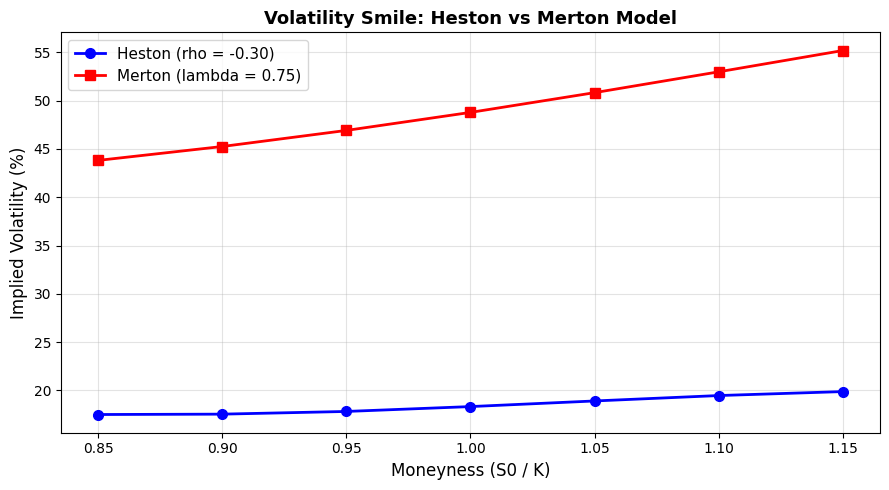

In [ ]:
# Q12: Volatility Smile (7 Strikes)
moneyness_vals = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
strikes = [round(S0 / m, 2) for m in moneyness_vals]

vol_smile_data = []
iv_heston, iv_merton = [], []

for m, K in zip(moneyness_vals, strikes):
    paths_h = heston_paths(S0, r, v0, kappa, theta, sigma_v, -0.30, T, N_steps, N_sim, seed=BASE_SEED)
    paths_m = merton_paths(S0, r, sigma_bs, T, 0.75, mu_j, delta_j, N_steps, N_sim, seed=BASE_SEED)

    c_h = euro_call_price_mc(paths_h, K, r, T)
    c_m = euro_call_price_mc(paths_m, K, r, T)

    iv_h = implied_vol(c_h, S0, K, r, T)
    iv_m = implied_vol(c_m, S0, K, r, T)
    iv_heston.append(iv_h)
    iv_merton.append(iv_m)

    iv_h_pct = round(iv_h * 100, 2) if not np.isnan(iv_h) else float('nan')
    iv_m_pct = round(iv_m * 100, 2) if not np.isnan(iv_m) else float('nan')

    vol_smile_data.append({
        "Moneyness": m, "Strike ($)": K,
        "Heston Call ($)": round(c_h, 2),
        "Heston IV (%)": iv_h_pct,
        "Merton Call ($)": round(c_m, 2),
        "Merton IV (%)": iv_m_pct
    })

df_smile = pd.DataFrame(vol_smile_data)
print("\nQ12: Volatility Smile:")
display(df_smile)

# ── Volatility Smile Plot ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(moneyness_vals, [v * 100 for v in iv_heston],
        'b-o', linewidth=2, markersize=7, label='Heston (rho = -0.30)')
ax.plot(moneyness_vals, [v * 100 for v in iv_merton],
        'r-s', linewidth=2, markersize=7, label='Merton (lambda = 0.75)')
ax.set_xlabel('Moneyness (S0 / K)', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('Volatility Smile: Heston vs Merton Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
ax.set_xticks(moneyness_vals)
plt.tight_layout()
plt.show()

---
### Step 2: Group Tasks
**Questions 13, 14, and 15**
Implementing the Longstaff-Schwartz algorithm for American option valuation, and evaluating conditional barrier structures (Up-and-In Calls, Down-and-In Puts).
*Note: The barrier and vanilla payoffs are evaluated on the exact same array of paths to eliminate Monte Carlo variance, isolating the true structural premium differences.*

Q13: American Call (Heston rho = -0.30)


,Option,Price ($),Delta,Gamma
0,European Call (Q5),3.4800,0.5995,0.0489
1,American Call (Q13),17.1400,12.6122,2463.8709



Early exercise premium: $13.66



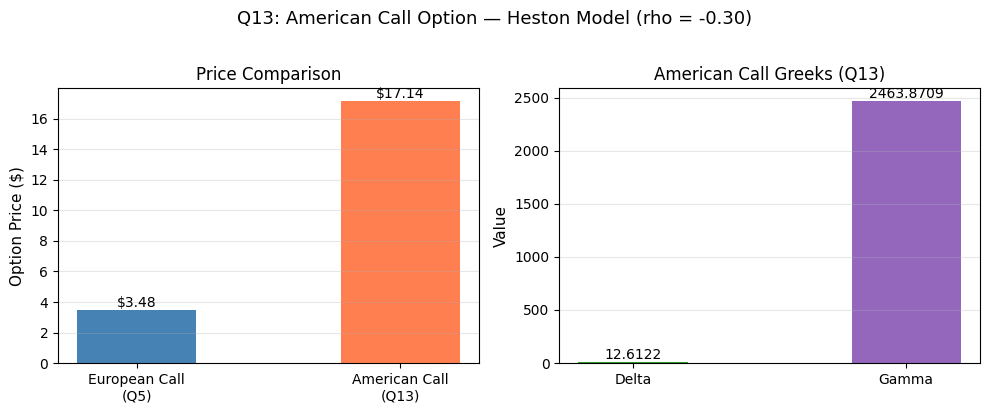

In [ ]:
# Q13: American Call (LSM Algorithm)
def lsm_american_call(S_paths, K, r, T):
    N_steps = S_paths.shape[0] - 1
    dt = T / N_steps
    disc = np.exp(-r * dt)

    cashflows = np.maximum(S_paths[-1] - K, 0.0)

    for t in range(N_steps - 1, 0, -1):
        St = S_paths[t]
        exercise_val = np.maximum(St - K, 0.0)
        itm = exercise_val > 0

        if np.sum(itm) < 5:
            cashflows *= disc
            continue

        X = St[itm]
        Y = cashflows[itm] * disc

        # Quadratic regression basis [1, S, S^2]
        coeffs = np.polyfit(X, Y, 1)
        cont_val = np.maximum(np.polyval(coeffs, X), 0.0)

        exercise_now = exercise_val[itm] >= cont_val

        cashflows *= disc
        idx_itm = np.where(itm)[0]
        ex_idx = idx_itm[exercise_now]

        cashflows[ex_idx] = exercise_val[ex_idx]

    return np.mean(cashflows) * disc

paths_q13_mid = heston_paths(S0, r, v0, kappa, theta, sigma_v, -0.30, T, N_steps, N_sim, seed=BASE_SEED).T
paths_q13_up = heston_paths(S0+h, r, v0, kappa, theta, sigma_v, -0.30, T, N_steps, N_sim, seed=BASE_SEED).T
paths_q13_dn = heston_paths(S0-h, r, v0, kappa, theta, sigma_v, -0.30, T, N_steps, N_sim, seed=BASE_SEED).T

am_mid = lsm_american_call(paths_q13_mid, K_ATM, r, T)
am_up = lsm_american_call(paths_q13_up, K_ATM, r, T)
am_dn = lsm_american_call(paths_q13_dn, K_ATM, r, T)

am_delta = (am_up - am_dn) / (2 * h)
am_gamma = (am_up - 2 * am_mid + am_dn) / (h ** 2)

c5 = df_A[df_A['Question'] == 'Q5']['Call Price ($)'].values[0]
c5_delta = df_A[df_A['Question'] == 'Q5']['Call Delta'].values[0]
c5_gamma = df_A[df_A['Question'] == 'Q5']['Call Gamma'].values[0]

df_q13 = pd.DataFrame({
    'Option':       ['European Call (Q5)', 'American Call (Q13)'],
    'Price ($)':    [c5,      round(am_mid, 2)],
    'Delta':        [c5_delta, round(am_delta, 4)],
    'Gamma':        [c5_gamma, round(am_gamma, 4)],
})

print("Q13: American Call (Heston rho = -0.30)")
display(df_q13)
print(f"\nEarly exercise premium: ${round(am_mid - c5, 2):.2f}\n")

# ── Q13 Visualization: European vs American Call ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: price comparison
opts   = ['European Call\n(Q5)', 'American Call\n(Q13)']
prices = [c5, am_mid]
bars = axes[0].bar(opts, prices, color=['steelblue', 'coral'], width=0.45)
axes[0].bar_label(bars, fmt='$%.2f', fontsize=10)
axes[0].set_ylabel('Option Price ($)', fontsize=11)
axes[0].set_title('Price Comparison', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Right: Greeks
greek_labels = ['Delta', 'Gamma']
greek_vals   = [am_delta, am_gamma]
colors       = ['#2ca02c', '#9467bd']
bars2 = axes[1].bar(greek_labels, greek_vals, color=colors, width=0.40)
axes[1].bar_label(bars2, fmt='%.4f', fontsize=10)
axes[1].set_ylabel('Value', fontsize=11)
axes[1].set_title('American Call Greeks (Q13)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Q13: American Call Option — Heston Model (rho = -0.30)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Q14 Output (Heston rho = -0.70):


,Question,Instrument,Strike ($),Barrier ($),Price ($)
0,Q14,Vanilla European Call,95.0000,None,0.0300
1,Q14,Up-and-In Call (CUI),95.0000,95.0000,0.0300



Relative discount: 0.00%



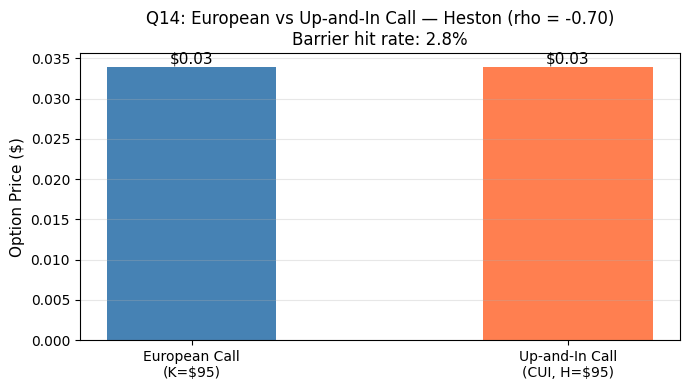

In [ ]:
# Q14: European Up-and-In Call (CUI)
H_cui, K_cui = 95.0, 95.0

paths_q14 = heston_paths(S0, r, v0, kappa, theta, sigma_v, -0.70, T, N_steps, N_sim, seed=BASE_SEED)
ST_q14 = paths_q14[-1]

barrier_hit_cui = np.max(paths_q14, axis=0) >= H_cui
payoff_cui = np.where(barrier_hit_cui, np.maximum(ST_q14 - K_cui, 0.0), 0.0)
cui_price = np.exp(-r * T) * payoff_cui.mean()
pct_hit_cui = 100.0 * barrier_hit_cui.mean()

vanilla_call_payoff = np.maximum(ST_q14 - K_cui, 0.0)
vanilla_call_price = np.exp(-r * T) * vanilla_call_payoff.mean()

df_q14 = pd.DataFrame({
    "Question": ["Q14", "Q14"],
    "Instrument": ["Vanilla European Call", "Up-and-In Call (CUI)"],
    "Strike ($)": [K_cui, K_cui],
    "Barrier ($)": ["None", H_cui],
    "Price ($)": [round(vanilla_call_price, 2), round(cui_price, 2)]
})

print("Q14 Output (Heston rho = -0.70):")
display(df_q14)
print(f"\nRelative discount: {1.0 - cui_price/vanilla_call_price:.2%}\n")

# ── Q14 Visualization: European Call vs Up-and-In Call ─────────────
fig, ax = plt.subplots(figsize=(7, 4))
opts   = ['European Call\n(K=$95)', 'Up-and-In Call\n(CUI, H=$95)']
prices = [vanilla_call_price, cui_price]
bars = ax.bar(opts, prices, color=['steelblue', 'coral'], width=0.45)
ax.bar_label(bars, fmt='$%.2f', fontsize=11)
ax.set_ylabel('Option Price ($)', fontsize=11)
ax.set_title(f'Q14: European vs Up-and-In Call — Heston (rho = -0.70)\n'
             f'Barrier hit rate: {pct_hit_cui:.1f}%', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Q15 Output (Merton lambda = 0.75):


,Question,Instrument,Strike ($),Barrier ($),Price ($)
0,Q15,Vanilla European Put,65.0000,None,2.7600
1,Q15,Down-and-In Put (PDI),65.0000,65.0000,2.7600



Relative discount: 0.00%



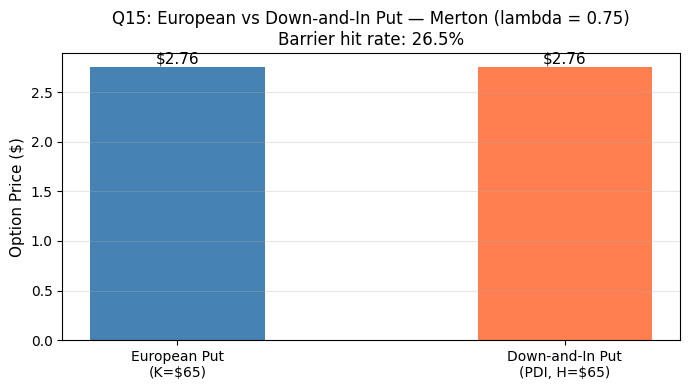

In [ ]:
# Q15: European Down-and-In Put (PDI)
H_pdi, K_pdi = 65.0, 65.0

paths_q15 = merton_paths(S0, r, sigma_bs, T, 0.75, mu_j, delta_j, N_steps, N_sim, seed=BASE_SEED)
ST_q15 = paths_q15[-1]

barrier_hit_pdi = np.min(paths_q15, axis=0) <= H_pdi
payoff_pdi = np.where(barrier_hit_pdi, np.maximum(K_pdi - ST_q15, 0.0), 0.0)
pdi_price = np.exp(-r * T) * payoff_pdi.mean()
pct_hit_pdi = 100.0 * barrier_hit_pdi.mean()

vanilla_put_payoff = np.maximum(K_pdi - ST_q15, 0.0)
vanilla_put_price = np.exp(-r * T) * vanilla_put_payoff.mean()

df_q15 = pd.DataFrame({
    "Question": ["Q15", "Q15"],
    "Instrument": ["Vanilla European Put", "Down-and-In Put (PDI)"],
    "Strike ($)": [K_pdi, K_pdi],
    "Barrier ($)": ["None", H_pdi],
    "Price ($)": [round(vanilla_put_price, 2), round(pdi_price, 2)]
})

print("Q15 Output (Merton lambda = 0.75):")
display(df_q15)
print(f"\nRelative discount: {1.0 - pdi_price/vanilla_put_price:.2%}\n")

# ── Q15 Visualization: European Put vs Down-and-In Put ────────────
fig, ax = plt.subplots(figsize=(7, 4))
opts   = ['European Put\n(K=$65)', 'Down-and-In Put\n(PDI, H=$65)']
prices = [vanilla_put_price, pdi_price]
bars = ax.bar(opts, prices, color=['steelblue', 'coral'], width=0.45)
ax.bar_label(bars, fmt='$%.2f', fontsize=11)
ax.set_ylabel('Option Price ($)', fontsize=11)
ax.set_title(f'Q15: European vs Down-and-In Put — Merton (lambda = 0.75)\n'
             f'Barrier hit rate: {pct_hit_pdi:.1f}%', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()